In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
import warnings
warnings.filterwarnings("ignore")

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/bengaluru-house-price-data/Bengaluru_House_Data.csv


In [3]:
df = pd.read_csv('/kaggle/input/bengaluru-house-price-data/Bengaluru_House_Data.csv')
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [4]:
print(df.shape)
df.columns

(13320, 9)


Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')

In [5]:
#check each columns value count
for columns in df.columns:
    print(df[columns].value_counts())


area_type
Super built-up  Area    8790
Built-up  Area          2418
Plot  Area              2025
Carpet  Area              87
Name: count, dtype: int64
availability
Ready To Move    10581
18-Dec             307
18-May             295
18-Apr             271
18-Aug             200
                 ...  
16-Oct               1
17-Jan               1
16-Nov               1
16-Jan               1
14-Jul               1
Name: count, Length: 81, dtype: int64
location
Whitefield                         540
Sarjapur  Road                     399
Electronic City                    302
Kanakpura Road                     273
Thanisandra                        234
                                  ... 
3rd Stage Raja Rajeshwari Nagar      1
Chuchangatta Colony                  1
Electronic City Phase 1,             1
Chikbasavanapura                     1
Abshot Layout                        1
Name: count, Length: 1305, dtype: int64
size
2 BHK         5199
3 BHK         4310
4 Bedroom      826
4 BH

In [6]:
df = df.drop(['area_type','society', 'balcony','availability'], axis ='columns')

In [7]:
df.isnull().sum()

location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64

In [8]:
df = df.dropna()

# EDA

In [9]:
#Converting size to numeric (2bhk to 2)
df['bhk'] = df['size'].apply(lambda x : int(x.split(' ')[0]))

In [10]:
  df.head()

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00,4
2,Uttarahalli,3 BHK,1440,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00,3
4,Kothanur,2 BHK,1200,2.0,51.00,2


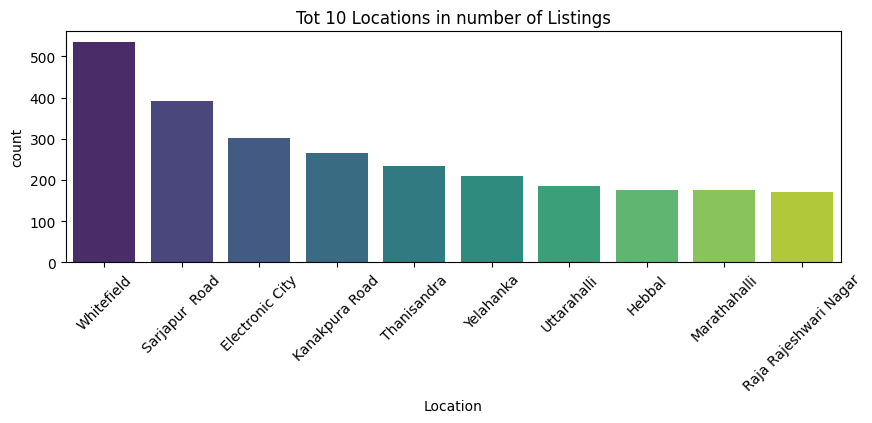

In [11]:
# top 10 locations
top_locations = df['location'].value_counts().head(10)
plt.figure(figsize=(10,3))
sns.barplot(x=top_locations.index, y=top_locations.values, palette='viridis', legend = 'False')
plt.xticks(rotation=45)
plt.title('Tot 10 Locations in number of Listings')
plt.xlabel('Location')
plt.ylabel('count')
plt.show()

# distibution of price

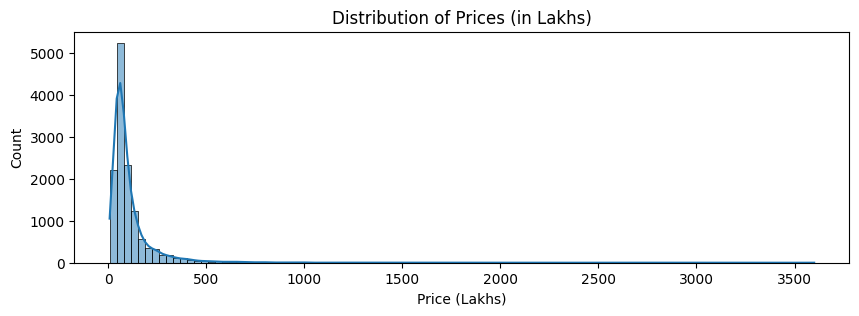

In [12]:
plt.figure(figsize=(10,3))
sns.histplot(df['price'], bins=100, kde=True)
plt.title('Distribution of Prices (in Lakhs)')
plt.xlabel('Price (Lakhs)')
plt.ylabel('Count')
plt.show()

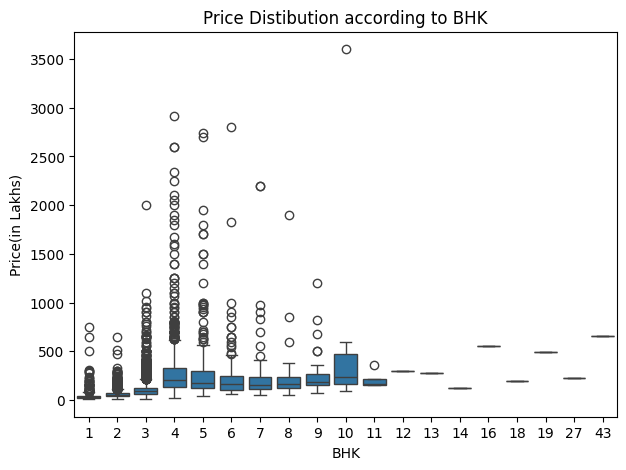

In [13]:
# price vs BHK Boxplot
plt.figure(figsize= (7,5))
sns.boxplot(x='bhk', y='price', data=df)
plt.title('Price Distibution according to BHK')
plt.xlabel('BHK')
plt.ylabel('Price(in Lakhs)')
plt.show()

In [14]:
print(df.head(3))
df.shape

                   location       size total_sqft  bath   price  bhk
0  Electronic City Phase II      2 BHK       1056   2.0   39.07    2
1          Chikka Tirupathi  4 Bedroom       2600   5.0  120.00    4
2               Uttarahalli      3 BHK       1440   2.0   62.00    3


(13246, 6)

# Feature Engineering and Data Cleaning

In [15]:
df['total_sqft'].sample(20)

4211               900
6288              1500
6427              1800
8532               800
12360             1200
589                961
9137              1080
10602             2400
2828              1200
3228     3040Sq. Meter
442               1400
8414              1395
6488              2400
5215              1733
3581              1500
8245              1200
6713              2500
4587              1730
4334              1500
5872              1760
Name: total_sqft, dtype: object

In [16]:
# Convert 'total_sqft' to a single numeric value
def convert_sqft_to_num(x):
    try:
        x = str(x)
        tokens = x.split('-')
        if len(tokens) == 2:
            return (float (tokens[0]) + float (tokens [1])) / 2
        return float(x)
    except:
        return None
df['total_sqft'] =df['total_sqft'].apply(convert_sqft_to_num)
# Drop rows with invalid or null 'total_sqft'
df = df.dropna (subset=['total_sqft'])
print("After sqft conversion:", df.shape)

After sqft conversion: (13200, 6)


# Calculating price per square foot

In [17]:
# Add new column: price per square foot
df['price_per_sqft'] = df['price'] * 100000 / df ['total_sqft']
#Price = 50 (lakhs) *50 × 100,000 = 5,000,000
#Total Sqft = 1000
#price_per_sqft 5,000,000 / 1000 = 5000 per sqft

# Cleaning and grouping location

In [18]:
# Clean 'location' text
df['location'] = df['location'].apply(lambda x: x.strip())
# Group rare locations as 'other'
location_counts = df ['location'].value_counts()
rare_locations = location_counts [location_counts <= 10].index
df['location'] = df ['location'].apply(lambda x: 'other' if x in rare_locations else x)
print("Unique locations:", len (df ['location'].unique()))


Unique locations: 241


# removing Unrealistically small BHK Config


In [19]:
#Removing Unrealistically Small BHK Configurations
# Remove rows where total_sqft per BHK is less than 300
df = df [df['total_sqft'] / df['bhk'] >= 300]
print("After removing low sqft per BHK: ", df.shape)

After removing low sqft per BHK:  (12456, 7)


# Removing Location-Wise Price per Sqft Outliers
 

In [20]:
# This function removes price_per_sqft outliers location-wise
def remove_pps_outliers (df):
    cleaned_df = pd.DataFrame() # Empty DataFrame to store clean data
    
# Group data by each location
    for location, group in df.groupby('location'):
        mean = group['price_per_sqft'].mean()
        std = group['price_per_sqft'].std()
        
# Keep only rows where price_per_sqft is within one std deviation from mean
        filtered = group[(group['price_per_sqft'] > (mean - std)) &
                         (group['price_per_sqft'] <= (mean + std))]
        
        cleaned_df = pd.concat([cleaned_df, filtered], ignore_index=True)
    return cleaned_df
# Apply the function to clean the dataset
df = remove_pps_outliers(df)
print( "After removing price_per_sqft outliers: ", df.shape)


After removing price_per_sqft outliers:  (10293, 7)


#  Removing BHK-Based Pricing Outliers

In [21]:
# This function removes BHK-based pricing outliers for each location
def remove_bhk_outliers(df):
    indices_to_remove = []  # Store indexes of outliers

    # Group data by each location
    for location, location_df in df.groupby('location'):
        # Create a dictionary to store price stats for each BHK level
        bhk_price_stats = {}

        # Loop through each BHK group in that location
        for bhk, bhk_df in location_df.groupby('bhk'):
            bhk_price_stats[bhk] = {
                'mean_price': bhk_df['price_per_sqft'].mean(),
                'std_dev': bhk_df['price_per_sqft'].std(),
                'count': bhk_df.shape[0]
            }

        # Now check if a higher BHK is priced less than the lower BHK's average
        for bhk, bhk_df in location_df.groupby('bhk'):
            lower_bhk_stats = bhk_price_stats.get(bhk - 1)
            if lower_bhk_stats and lower_bhk_stats['count'] > 5:
                # If this BHK is priced less than the previous BHK's average → outlier
                bad_bhk = bhk_df[bhk_df['price_per_sqft'] < lower_bhk_stats['mean_price']]
                indices_to_remove.extend(bad_bhk.index)

    # Drop all detected outliers
    return df.drop(indices_to_remove, axis='index')

# Apply the function
df = remove_bhk_outliers(df)

print("✅ After removing BHK outliers:", df.shape)

✅ After removing BHK outliers: (7365, 7)


# Removing Unrealistic Bathroom Counts

In [22]:
# Keep rows where number of bathrooms is reasonable
df = df[df['bath'] < df['bhk'] + 2]

print("After removing bathroom outliers:", df.shape)

After removing bathroom outliers: (7286, 7)


In [23]:
# Drop unused columns
df_model = df.drop(['size', 'price_per_sqft'], axis=1)
df_model.head()

,location,total_sqft,bath,price,bhk
0,1st Block Jayanagar,2850.0,4.0,428.0,4
1,1st Block Jayanagar,1630.0,3.0,194.0,3
2,1st Block Jayanagar,1875.0,2.0,235.0,3
3,1st Block Jayanagar,1200.0,2.0,130.0,3
4,1st Block Jayanagar,1235.0,2.0,148.0,2


In [24]:
#One-Hot Encode Location Column¶
df['location'].unique()

array(['1st Block Jayanagar', '1st Phase JP Nagar',
       '2nd Phase Judicial Layout', '2nd Stage Nagarbhavi',
       '5th Block Hbr Layout', '5th Phase JP Nagar', '6th Phase JP Nagar',
       '7th Phase JP Nagar', '8th Phase JP Nagar', '9th Phase JP Nagar',
       'AECS Layout', 'Abbigere', 'Akshaya Nagar', 'Ambalipura',
       'Ambedkar Nagar', 'Amruthahalli', 'Anandapura', 'Ananth Nagar',
       'Anekal', 'Anjanapura', 'Ardendale', 'Arekere', 'Attibele',
       'BEML Layout', 'BTM 2nd Stage', 'BTM Layout', 'Babusapalaya',
       'Badavala Nagar', 'Balagere', 'Banashankari',
       'Banashankari Stage II', 'Banashankari Stage III',
       'Banashankari Stage V', 'Banashankari Stage VI', 'Banaswadi',
       'Banjara Layout', 'Bannerghatta', 'Bannerghatta Road',
       'Basavangudi', 'Basaveshwara Nagar', 'Battarahalli', 'Begur',
       'Begur Road', 'Bellandur', 'Benson Town', 'Bharathi Nagar',
       'Bhoganhalli', 'Billekahalli', 'Binny Pete', 'Bisuvanahalli',
       'Bommanahalli'

In [25]:
# Create dummy variables (one-hot encoding) for location
dummies = pd.get_dummies(df_model['location'], dtype=int)
df_model = pd.concat([df_model.drop('location', axis=1), dummies.drop('other', axis=1)], axis=1)

print("Final shape after encoding:", df_model.shape)

Final shape after encoding: (7286, 244)


# Train Test Split

In [26]:
# Split features and label
X = df_model.drop('price', axis=1)
y = df_model['price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (5828, 243)
X_test shape: (1458, 243)


# LinearRegression

In [27]:
# Train a Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Evaluate on test set
y_pred = lr_model.predict(X_test)
lr_r2 = r2_score(y_test, y_pred)

print("📉 Linear Regression R² Score:", round(lr_r2, 3))

📉 Linear Regression R² Score: 0.855


# randomForest Regressor

In [28]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Train a Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate on test set
y_pred_rf = rf_model.predict(X_test)
rf_r2 = r2_score(y_test, y_pred_rf)

print("🌲 Random Forest R² Score:", round(rf_r2, 3))

🌲 Random Forest R² Score: 0.84


# XGBoost Regressor

In [29]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

# Train an XGBoost model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

# Evaluate on test set
y_pred_xgb = xgb_model.predict(X_test)
xgb_r2 = r2_score(y_test, y_pred_xgb)

print("🚀 XGBoost R² Score:", round(xgb_r2, 3))

🚀 XGBoost R² Score: 0.859


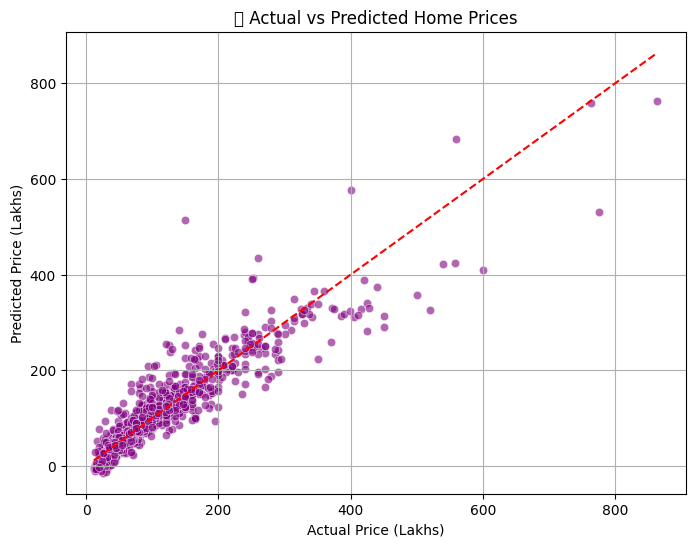

In [30]:
# Scatter plot of Actual vs Predicted
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')  # Diagonal line
plt.xlabel('Actual Price (Lakhs)')
plt.ylabel('Predicted Price (Lakhs)')
plt.title('🔍 Actual vs Predicted Home Prices')
plt.grid(True)
plt.show()

In [31]:
import joblib

# Save the model
joblib.dump(lr_model, 'linear_regression_model.pkl')

# Load the model
# loaded_model = joblib.load('linear_regression_model.pkl')

['linear_regression_model.pkl']